# t-tests on different data: chick feeds & textbook prices

*Part 2 · Lesson 15 · another dataset  ·  data: Chickwts · Textbooks (paired)*

*↩ A companion to [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb).*

**↩ Back:** [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](15-t-tests~the-code.ipynb)

The core t-tests lesson met the **t-distribution** and three everyday tests — one-sample, two-sample, and
paired — using guinea-pig tooth growth and 12 timed swimmers. The ideas don't depend on those datasets,
so here we run the very same machinery on two fresh ones and watch the *logic* repeat:

- **Chickwts** — a clean, near-balanced experiment: baby chicks were fed one of several diets and then
  weighed. We'll compare two feeds (**casein** vs **horsebean**) with a **two-sample** test, where the
  effect is huge and the verdict never in doubt.
- **Textbooks** — a different flavour of **paired** design: the *same* 73 textbooks, each priced two ways
  — at the **campus bookstore** and on **Amazon**. Because each book is its own control, pairing strips
  away the enormous book-to-book price spread.

The punchline mirrors the swim data but on prices: when two numbers come from the *same unit*, pairing can
turn a non-result into a slam dunk. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

CHICK_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/chickwts.csv'
TEXT_URL = 'https://www.openintro.org/data/csv/textbooks.csv'

ch = sl.load_csv('chickwts.csv', url=CHICK_URL)
txt = sl.load_csv('textbooks.csv', url=TEXT_URL)

# Chickwts: 71 newly-hatched chicks, each fed ONE diet for six weeks; 'weight'
# is the chick's weight in grams (the response), 'feed' is which of 6 diets.
print(f'Chickwts: {len(ch)} chicks   ·   feed types: {sorted(ch["feed"].unique())}')
# Textbooks: the SAME 73 books, each priced at the UCLA store and on Amazon.
print(f'Textbooks: {len(txt)} books, each priced two ways (campus store vs online)')
ch.head()

Chickwts: 71 chicks   ·   feed types: ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']
Textbooks: 73 books, each priced two ways (campus store vs online)


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


## 1) A quick refresher: **t**, not z, and the cost of estimating $\sigma$

When we compare means we build a **t-statistic** — a signal-to-noise ratio of "how far is the mean from
what the null claims?" divided by "how much does a mean of this size typically wobble?":

$$t = \frac{\text{estimate} - \text{null value}}{\text{standard error}}.$$

It looks just like a z-score, but the standard error is built from the **sample** spread $s$, not the
true population spread $\sigma$ (which we never have). Because $s$ is itself an estimate that wobbles, the
honest reference curve is the **t-distribution** — the normal's more cautious cousin, with **heavier
tails** when data are scarce. Its one knob is the **degrees of freedom** $df$: small $df$ means fat tails
(extra caution), and as $df$ grows the t-curve slims into the normal. Here is that picture again, since it
governs every test below.

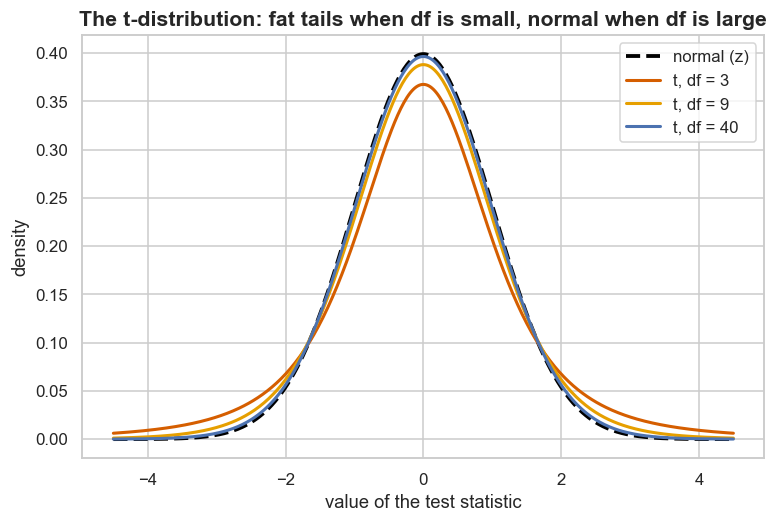

df =    3:  t* (95% two-sided) = 3.182
df =    9:  t* (95% two-sided) = 2.262
df =   40:  t* (95% two-sided) = 2.021
df = 1000:  t* (95% two-sided) = 1.962
normal z* (95% two-sided)        = 1.960   <- the limit t* approaches


In [2]:
xs = np.linspace(-4.5, 4.5, 400)
fig, ax = plt.subplots()
ax.plot(xs, stats.norm.pdf(xs), color='black', lw=2.5, ls='--', label='normal (z)')
for df, col in [(3, '#D55E00'), (9, '#E69F00'), (40, '#4c72b0')]:
    ax.plot(xs, stats.t.pdf(xs, df), color=col, lw=2, label=f't, df = {df}')
ax.set_xlabel('value of the test statistic'); ax.set_ylabel('density')
ax.set_title('The t-distribution: fat tails when df is small, normal when df is large')
ax.legend(); plt.show()

# The "~2" cutoff for 95% two-sided gets larger when df is small, shrinking toward 1.96.
for df in [3, 9, 40, 1000]:
    print(f'df = {df:>4}:  t* (95% two-sided) = {stats.t.ppf(0.975, df):.3f}')
print(f'normal z* (95% two-sided)        = {stats.norm.ppf(0.975):.3f}   <- the limit t* approaches')

The red `df = 3` curve has visibly heavier tails: with little information the cutoff for "surprising" is
pushed out to $t^{*} = 3.18$ instead of the normal's $1.96$. By `df = 40` the two curves have all but
merged. **Takeaway:** the t-distribution simply pays an honest tax for not knowing $\sigma$, and that tax
fades as the sample grows.

## 2) One-sample t-test — a building block

Before comparing two things, recall the simplest test: is **one** group's mean different from a target
number? The chicks were weighed after six weeks; suppose a hatchery's nominal six-week target weight is
**250 grams**. Take just the **casein**-fed chicks — is their mean weight really different from 250?

- **Null hypothesis** $H_0$: the true casein mean equals the target, $\mu = 250$.
- **Alternative** $H_a$: it does not, $\mu \neq 250$ (a two-sided test).

The recipe, simulation-first: **pretend the null is true**, manufacture the world of t-statistics it would
produce, and see how unusual our real data looks against it.

In [3]:
casein = ch.loc[ch['feed'] == 'casein', 'weight'].to_numpy()
mu0 = 250.0
n = len(casein)
xbar, s = casein.mean(), casein.std(ddof=1)
se = s / np.sqrt(n)
t_obs = (xbar - mu0) / se

print(f'Casein group: n = {n}, mean = {xbar:.1f} g, s = {s:.1f} g')
print(f'standard error  s/sqrt(n) = {se:.2f} g')
print(f'observed t = (mean - 250) / SE = {t_obs:.3f}')

Casein group: n = 12, mean = 323.6 g, s = 64.4 g
standard error  s/sqrt(n) = 18.60 g
observed t = (mean - 250) / SE = 3.956


### Build the null distribution by simulation

If $H_0$ were true and the weights were roughly normal, samples of size $n$ drawn from a population
centered at $\mu_0 = 250$ would scatter t-statistics around 0. We don't know the true shape, so we use a
faithful stand-in: **recenter our own sample** so its mean is exactly 250 (forcing $H_0$ to hold), then
**bootstrap-resample** it (draw a fresh sample of the same size by picking values from it at random, with
repeats allowed) thousands of times and recompute $t$ each time. The pile of simulated t's *is*
the null distribution — no formula required.

simulated two-sided p-value = 0.0090


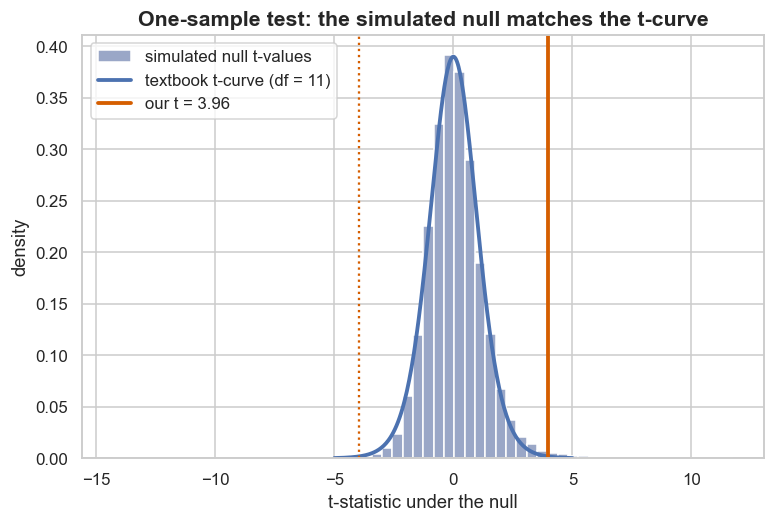

In [4]:
rng = np.random.default_rng(17)        # change this seed to re-roll the simulation
n_sims = 20000

null_centered = casein - xbar + mu0    # shift the sample so its mean is exactly mu0 = 250 (H0 true)
sim_t = np.empty(n_sims)
for i in range(n_sims):
    resample = rng.choice(null_centered, size=n, replace=True)
    sim_t[i] = (resample.mean() - mu0) / (resample.std(ddof=1) / np.sqrt(n))

# Two-sided p-value: how often is a simulated |t| at least as extreme as ours?
p_sim = np.mean(np.abs(sim_t) >= abs(t_obs))
print(f'simulated two-sided p-value = {p_sim:.4f}')

fig, ax = plt.subplots()
ax.hist(sim_t, bins=60, density=True, color='#9aa7c7', edgecolor='white',
        label='simulated null t-values')
grid = np.linspace(-5, 5, 300)
ax.plot(grid, stats.t.pdf(grid, df=n - 1), color='#4c72b0', lw=2.5,
        label=f'textbook t-curve (df = {n-1})')
ax.axvline(t_obs, color='#D55E00', lw=2.5, label=f'our t = {t_obs:.2f}')
ax.axvline(-t_obs, color='#D55E00', lw=1.5, ls=':')
ax.set_xlabel('t-statistic under the null'); ax.set_ylabel('density')
ax.set_title('One-sample test: the simulated null matches the t-curve')
ax.legend(); plt.show()

The grey histogram of *simulated* null t-values lands right on top of the blue **textbook t-curve** — that
curve is not magic, it is the shape this simulation produces. Our red line sits well out in a thin tail, so
the casein mean is comfortably above the 250-gram target. Confirm with the one-line library call.

In [5]:
res = stats.ttest_1samp(casein, popmean=mu0)
print(f'scipy ttest_1samp:  t = {res.statistic:.3f},  p = {res.pvalue:.4f},  df = {res.df}')
print(f'our simulation:     t = {t_obs:.3f},  p = {p_sim:.4f}   (they agree)')

# The confidence interval for the casein mean is the same machinery, read the other way.
ci = res.confidence_interval(confidence_level=0.95)
print(f'\n95% CI for the true casein mean: ({ci.low:.1f}, {ci.high:.1f}) g')
print(f'The target 250 is {"INSIDE" if ci.low <= mu0 <= ci.high else "OUTSIDE"} the interval.')

scipy ttest_1samp:  t = 3.956,  p = 0.0022,  df = 11
our simulation:     t = 3.956,  p = 0.0090   (they agree)

95% CI for the true casein mean: (282.6, 364.5) g
The target 250 is OUTSIDE the interval.


**Reading it three ways:**

- **The math:** $t = (\bar{x}-\mu_0)/(s/\sqrt{n})$ on $df = 11$, giving a small p-value.
- **The meaning:** if the true casein mean really were 250 g, a sample this far from 250 would be rare — so
  we **reject $H_0$**.
- **The real world:** the casein-fed chicks weigh clearly more than 250 g on average, and the 95% CI for
  their mean **excludes** 250, telling us not just *whether* but roughly *how much* heavier.

> **The CI and the test are the same coin.** A two-sided test rejects $H_0\!: \mu=\mu_0$ at the 5% level
> **exactly when** the 95% CI excludes $\mu_0$. They never disagree.

The one-sample test is the workhorse engine; the two-sample and paired tests below are both built from it.

## 3) Two-sample t-test — comparing two independent groups

Now the real question Chickwts was designed for: **does the diet matter?** Compare the **casein** chicks
against the **horsebean** chicks. These are *different* chicks, so the two groups are **independent** — the
classic two-sample setup.

- $H_0$: the two feeds give the same true mean weight ($\mu_{\text{casein}} = \mu_{\text{horsebean}}$).
- $H_a$: the means differ.

We'll use **Welch's** t-test (`equal_var=False`), the safe default that does **not** assume the two groups
share the same variance. Build the null first — this time by **shuffling labels**.

In [6]:
horsebean = ch.loc[ch['feed'] == 'horsebean', 'weight'].to_numpy()
obs_diff = casein.mean() - horsebean.mean()
print(f'casein:    n = {len(casein):>2}, mean = {casein.mean():.1f} g, s = {casein.std(ddof=1):.1f} g')
print(f'horsebean: n = {len(horsebean):>2}, mean = {horsebean.mean():.1f} g, s = {horsebean.std(ddof=1):.1f} g')
print(f'observed difference in means (casein - horsebean) = {obs_diff:.1f} g')

casein:    n = 12, mean = 323.6 g, s = 64.4 g
horsebean: n = 10, mean = 160.2 g, s = 38.6 g
observed difference in means (casein - horsebean) = 163.4 g


### The permutation idea — what if the feed labels meant nothing?

Here's the cleanest way to picture the null "the feed doesn't matter." If the casein/horsebean label truly
had no effect, it's just a *sticker* on each chick — we could **shuffle the labels at random** and the gap
between the two groups should be no bigger than what we see. So: pool all the weights, repeatedly deal them
back into a fake "casein" pile and "horsebean" pile, and record the difference in means each time. That
pile of shuffled differences is the null distribution.

> **A fine point.** Label-permutation is the exact-test analog of the **pooled** (equal-variance)
> two-sample t-test, not strictly Welch's. The groups here are nearly balanced (12 vs 10), so the pooled
> and Welch tests very nearly coincide and the permutation p-value tracks Welch closely.

permutation two-sided p-value = 0.00000   (0 means: never that extreme in 20,000 shuffles)


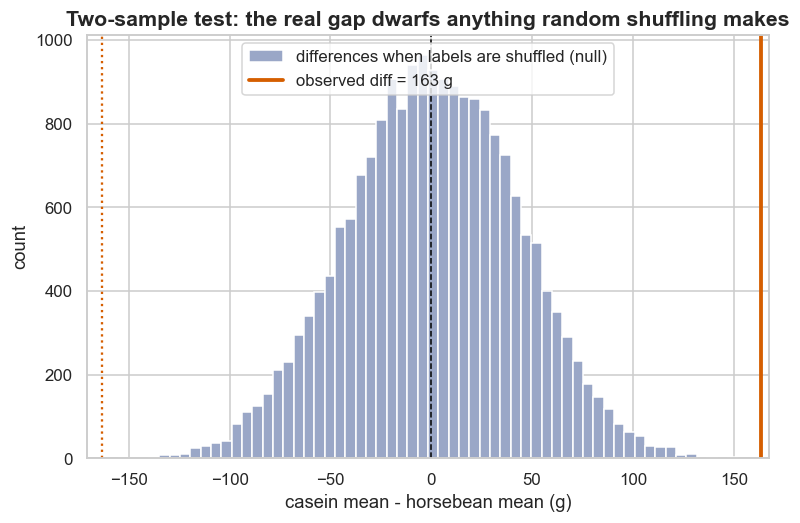

In [7]:
pooled = np.concatenate([casein, horsebean])
n_cas = len(casein)
perm_diffs = np.empty(n_sims)
for i in range(n_sims):
    rng.shuffle(pooled)
    perm_diffs[i] = pooled[:n_cas].mean() - pooled[n_cas:].mean()

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f'permutation two-sided p-value = {p_perm:.5f}   (0 means: never that extreme in {n_sims:,} shuffles)')

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=60, color='#9aa7c7', edgecolor='white',
        label='differences when labels are shuffled (null)')
ax.axvline(obs_diff, color='#D55E00', lw=2.5, label=f'observed diff = {obs_diff:.0f} g')
ax.axvline(-obs_diff, color='#D55E00', lw=1.5, ls=':')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('casein mean - horsebean mean (g)'); ax.set_ylabel('count')
ax.set_title('Two-sample test: the real gap dwarfs anything random shuffling makes')
ax.legend(); plt.show()

In [8]:
welch = stats.ttest_ind(casein, horsebean, equal_var=False)   # Welch's t-test (unequal variances)
ci = welch.confidence_interval(confidence_level=0.95)
print(f'Welch two-sample t-test:  t = {welch.statistic:.3f},  p = {welch.pvalue:.2e},  df = {welch.df:.1f}')
print(f'permutation test:                       p = {p_perm:.5f}   (close agreement)')
print(f'\n95% CI for the difference (casein - horsebean): ({ci.low:.1f}, {ci.high:.1f}) g')
print(f'Zero is {"INSIDE" if ci.low <= 0 <= ci.high else "OUTSIDE"} this interval.')

Welch two-sample t-test:  t = 7.342,  p = 7.21e-07,  df = 18.4
permutation test:                       p = 0.00000   (close agreement)

95% CI for the difference (casein - horsebean): (116.7, 210.1) g
Zero is OUTSIDE this interval.


**Reading it:** casein chicks averaged about 163 grams heavier than horsebean chicks, with $t \approx 7.3$
and $p \approx 7 \times 10^{-7}$ — and the 95% CI for the difference sits **far above zero**. The observed
gap is so large that in 20,000 random label-shuffles we essentially **never** saw anything like it.

This is the opposite extreme from the core lesson's OJ-vs-VC comparison, which was borderline
($p\approx0.06$). Here the effect is enormous and the verdict is never in doubt:

> **A clean designed experiment with a big effect.** Random assignment of chicks to feeds means the only
> systematic difference between the groups is the diet, and the gap is so wide relative to the within-group
> spread that even tiny samples (10–12 birds) settle it decisively. Casein is a far better feed than
> horsebean.

## 4) Paired t-test — when the two numbers come from the same unit

The two-sample test treats the groups as unrelated. But sometimes each *unit* gives you **both** numbers —
a before/after, a left/right, the same item measured two ways. That's a **paired** design, and ignoring
the pairing throws away its biggest advantage.

The **Textbooks** data is a different flavour of pairing from the swimmers in the core lesson: instead of
the same person timed twice, it's the **same book** priced twice — once at the **UCLA campus store**
(`ucla_new`) and once on **Amazon** (`amaz_new`). Because it's the *same book* in both columns, the right
move is to collapse each pair to its **difference** and ask whether the *mean difference* is zero.

- $H_0$: the mean within-book price difference is 0 (the two sellers charge the same on average).
- $H_a$: the mean difference is not 0.

In [9]:
ucla = txt['ucla_new'].to_numpy()      # campus bookstore price (dollars)
amaz = txt['amaz_new'].to_numpy()      # Amazon price (dollars)
d = ucla - amaz                        # one number per book: how much more the campus store charges

print('book  ucla_store  amazon  difference')
for i in range(8):                     # first 8 of 73 books
    print(f'  {i+1:>2}     {ucla[i]:7.2f}  {amaz[i]:6.2f}   {d[i]:+8.2f}')
print('   ...')
print(f'\nmean difference = {d.mean():+.2f} dollars   (s = {d.std(ddof=1):.2f}, n = {len(d)})')

book  ucla_store  amazon  difference
   1       27.67   27.95      -0.28
   2       40.59   31.14      +9.45
   3       31.68   32.00      -0.32
   4       16.00   11.52      +4.48
   5       18.95   14.21      +4.74
   6       14.95   10.17      +4.78
   7       24.70   20.06      +4.64
   8       19.50   16.66      +2.84
   ...

mean difference = +12.76 dollars   (s = 14.26, n = 73)


On average the campus store charges about **12.76 dollars more** per book. A paired t-test is nothing more
than a **one-sample t-test on the differences**, testing them against 0 — the exact recipe from Section 2.
Recenter the differences to have mean 0 (forcing $H_0$), bootstrap, and read off the p-value.

In [10]:
n_d = len(d)
t_paired_obs = d.mean() / (d.std(ddof=1) / np.sqrt(n_d))

null_d = d - d.mean()                  # force the mean difference to 0 (H0 true)
sim_td = np.empty(n_sims)
for i in range(n_sims):
    rs = rng.choice(null_d, size=n_d, replace=True)
    sd = rs.std(ddof=1)
    sim_td[i] = rs.mean() / (sd / np.sqrt(n_d)) if sd > 0 else 0.0

p_paired_sim = np.mean(np.abs(sim_td) >= abs(t_paired_obs))
print(f'observed paired t = {t_paired_obs:.2f}')
print(f'simulated null p-value = {p_paired_sim:.6f}   (0 means: never saw anything so extreme)')

# Confirm with scipy two ways: ttest_rel on the pairs == ttest_1samp on the differences.
rel = stats.ttest_rel(ucla, amaz)
one = stats.ttest_1samp(d, 0.0)
print(f'\nscipy ttest_rel(ucla, amaz):  t = {rel.statistic:.2f},  p = {rel.pvalue:.2e}')
print(f'scipy ttest_1samp(d, 0):      t = {one.statistic:.2f},  p = {one.pvalue:.2e}   (identical)')

ci = one.confidence_interval(confidence_level=0.95)
print(f'\n95% CI for the mean price gap (ucla - amazon): ({ci.low:.2f}, {ci.high:.2f}) dollars')

observed paired t = 7.65
simulated null p-value = 0.000000   (0 means: never saw anything so extreme)

scipy ttest_rel(ucla, amaz):  t = 7.65,  p = 6.93e-11
scipy ttest_1samp(d, 0):      t = 7.65,  p = 6.93e-11   (identical)

95% CI for the mean price gap (ucla - amazon): (9.44, 16.09) dollars


The campus-store premium is unmistakable: $t \approx 7.65$, $p \approx 7 \times 10^{-11}$, and a 95% CI of
roughly 9.5 to 16 dollars that sits comfortably above zero. In 20,000 simulated null worlds we essentially
never saw a gap this big by chance. On average, buying these books at the campus store costs about
**12.76 dollars more** apiece than buying them online.

## 5) Why pairing matters — the headline demonstration

Here's the punchline of the whole lesson. **Watch what happens if we *ignore* the pairing** and (wrongly)
run a two-sample test, treating the 73 campus prices and 73 Amazon prices as two unrelated groups.

In [11]:
paired_test = stats.ttest_rel(ucla, amaz)                       # CORRECT: respects the pairing
unpaired_test = stats.ttest_ind(ucla, amaz, equal_var=False)    # WRONG here: pretends the columns are unrelated

print('SAME 146 prices, two analyses:')
print(f'  PAIRED   (correct):  t = {paired_test.statistic:5.2f},  p = {paired_test.pvalue:.2e}   -> overwhelmingly significant')
print(f'  UNPAIRED (wrong):    t = {unpaired_test.statistic:5.2f},  p = {unpaired_test.pvalue:.3f}   -> NOT significant')

SAME 146 prices, two analyses:
  PAIRED   (correct):  t =  7.65,  p = 6.93e-11   -> overwhelmingly significant
  UNPAIRED (wrong):    t =  1.41,  p = 0.160   -> NOT significant


Same data, opposite verdict. The correct **paired** test screams "the campus store is pricier"
($p \approx 7\times10^{-11}$); the **unpaired** test shrugs ($p \approx 0.16$). How can ignoring the
pairing flip a slam-dunk result into a null one? The answer is the enormous **book-to-book** price
variation — cheap paperbacks next to expensive hardcover texts.

In [12]:
# The standard error is what differs. Compare the two SEs directly.
se_paired = d.std(ddof=1) / np.sqrt(n_d)
sp = np.sqrt(((len(ucla)-1)*ucla.var(ddof=1) + (len(amaz)-1)*amaz.var(ddof=1)) / (len(ucla)+len(amaz)-2))
se_unpaired = sp * np.sqrt(1/len(ucla) + 1/len(amaz))

print(f'Spread of individual prices: campus s = {ucla.std(ddof=1):.1f},  Amazon s = {amaz.std(ddof=1):.1f} dollars  (huge!)')
print(f'Spread of the DIFFERENCES:   s = {d.std(ddof=1):.1f} dollars  (much smaller)')
print()
print(f'SE of the mean gap, PAIRED   = {se_paired:.2f} dollars')
print(f'SE of the mean gap, UNPAIRED = {se_unpaired:.2f} dollars')
print(f'-> the paired SE is about {se_unpaired/se_paired:.0f}x smaller, so the same gap looks far more decisive.')
print(f'\nWhy? campus & Amazon prices are correlated r = {np.corrcoef(ucla, amaz)[0,1]:.3f}:')
print('an expensive book is expensive at BOTH sellers. Pairing subtracts away that book-to-book spread.')

Spread of individual prices: campus s = 59.7,  Amazon s = 49.0 dollars  (huge!)
Spread of the DIFFERENCES:   s = 14.3 dollars  (much smaller)

SE of the mean gap, PAIRED   = 1.67 dollars
SE of the mean gap, UNPAIRED = 9.04 dollars
-> the paired SE is about 5x smaller, so the same gap looks far more decisive.

Why? campus & Amazon prices are correlated r = 0.985:
an expensive book is expensive at BOTH sellers. Pairing subtracts away that book-to-book spread.


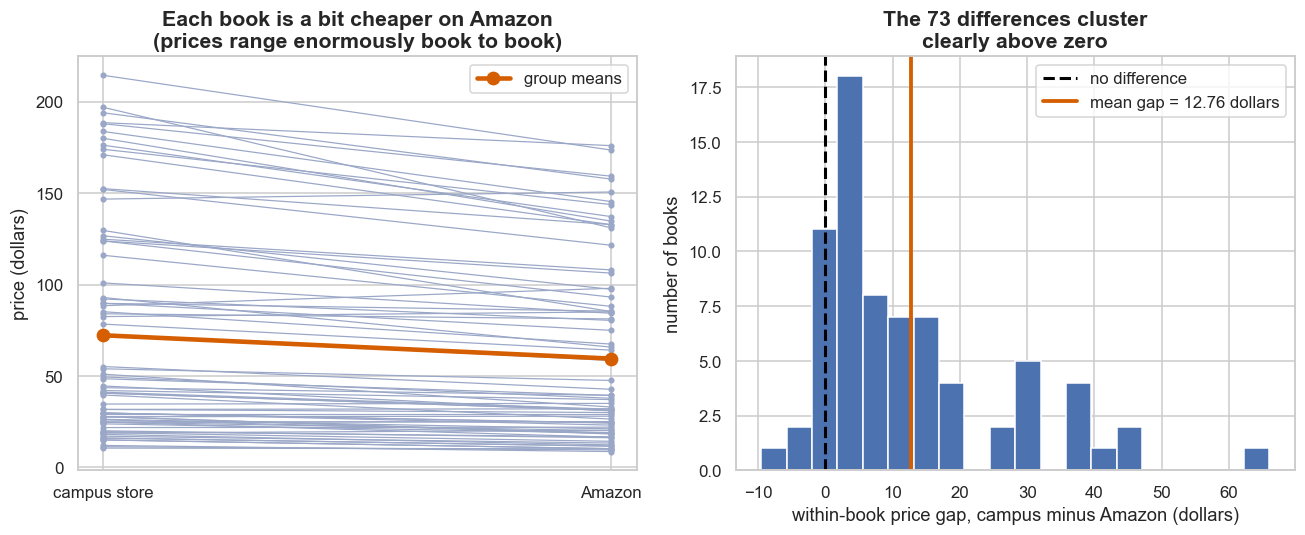

In [13]:
# A picture: connect each book's two prices. The lines barely cross and almost all tilt the same way
# -- THAT consistency is the signal the unpaired test throws away in the sea of book-to-book variation.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

for i in range(n_d):
    axL.plot([0, 1], [ucla[i], amaz[i]], color='#9aa7c7', lw=0.8, marker='o', ms=3)
axL.plot([0, 1], [ucla.mean(), amaz.mean()], color='#D55E00', lw=3, marker='o',
         ms=8, label='group means')
axL.set_xticks([0, 1]); axL.set_xticklabels(['campus store', 'Amazon'])
axL.set_ylabel('price (dollars)')
axL.set_title('Each book is a bit cheaper on Amazon\n(prices range enormously book to book)')
axL.legend()

axR.hist(d, bins=20, color='#4c72b0', edgecolor='white')
axR.axvline(0, color='black', lw=2, ls='--', label='no difference')
axR.axvline(d.mean(), color='#D55E00', lw=2.5, label=f'mean gap = {d.mean():.2f} dollars')
axR.set_xlabel('within-book price gap, campus minus Amazon (dollars)'); axR.set_ylabel('number of books')
axR.set_title('The 73 differences cluster\nclearly above zero')
axR.legend()
plt.tight_layout(); plt.show()

On the **left**, the raw prices fan out wildly — some books near 10 dollars, others well over 100 — and an
unpaired test sees those two big overlapping clouds and concludes it can't tell them apart. But almost
every connecting line tilts the same way (down toward Amazon). The **right** panel shows the trick: once
you look at each book's *own* price gap, the 73 differences huddle clearly above zero. **Pairing cancels
the between-book variation**, leaving only the clean campus-store premium — which is why the paired SE was
about 5x smaller.

**The real-world lesson:** if your data are naturally matched (before/after, twins, left/right, the same
item measured two ways), *use the pairing.* As with the swimmers in the core lesson, it is often the
difference between detecting an effect and missing it — and "paired vs two-sample" comes down to one
question: **do the two numbers come from the same unit?** For the chicks, no (different birds → two-sample);
for the textbooks, yes (same book → paired).

## 6) Assumptions & robustness — when can you trust a t-test?

The t-test isn't unconditional. Its key assumptions:

1. **Independent observations** (within each group). The whole *point* of the paired test is to handle the
   one dependence we expect — the link between a unit's two measurements — by reducing to one number per
   unit.
2. **Roughly normal** data — specifically, the **sampling distribution of the mean** should be near normal.
   For the *paired* test this means the **differences** should be roughly normal, not the raw values.
3. For the **two-sample** test, equal variances are *not* required if you use **Welch's** version (the
   default we used).

The good news is **robustness**: thanks to the Central Limit Theorem, the t-test holds up well even for
non-normal data once $n$ is moderately large, because the *mean* becomes normal regardless. It's most
fragile with **small samples of skewed data with outliers**. Let's check the 73 textbook differences with a
normal-quantile (Q-Q) plot — if the points hug the line, normality is a fair assumption.

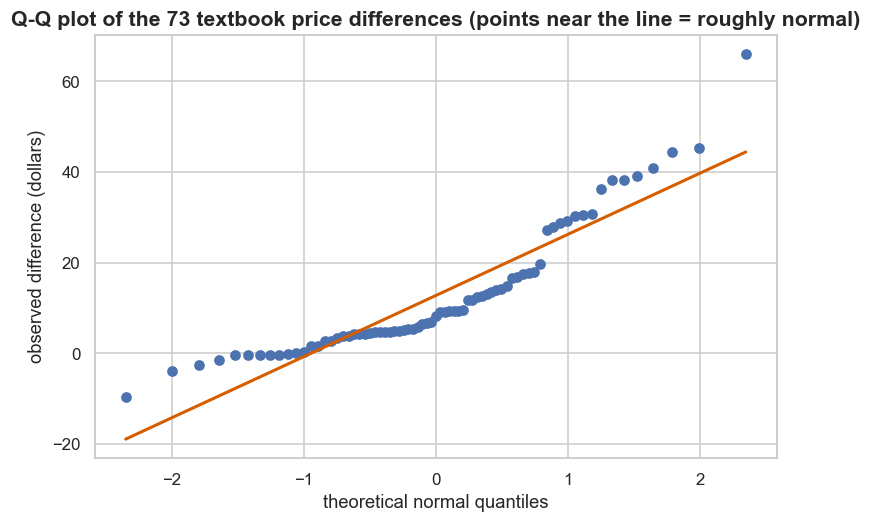

Shapiro-Wilk normality test on the differences: W = 0.865, p = 0.0000
The center is near-normal; a few heavy-discount books make the tails a touch long, but with
n = 73 the CLT keeps the paired t-test on safe ground (and the effect is huge either way).


In [14]:
fig, ax = plt.subplots()
stats.probplot(d, dist='norm', plot=ax)
ax.get_lines()[0].set_color('#4c72b0'); ax.get_lines()[0].set_markersize(6)
ax.get_lines()[1].set_color('#D55E00'); ax.get_lines()[1].set_linewidth(2)
ax.set_title('Q-Q plot of the 73 textbook price differences (points near the line = roughly normal)')
ax.set_xlabel('theoretical normal quantiles'); ax.set_ylabel('observed difference (dollars)')
plt.show()

# A formal sanity check. With n = 73 the t-test is robust regardless, but it's worth a look.
w_stat, w_p = stats.shapiro(d)
print(f'Shapiro-Wilk normality test on the differences: W = {w_stat:.3f}, p = {w_p:.4f}')
print('The center is near-normal; a few heavy-discount books make the tails a touch long, but with')
print('n = 73 the CLT keeps the paired t-test on safe ground (and the effect is huge either way).')

## Now you try

Predict the result first, then change a number and re-run:

1. **A different one-sample target.** In Section 2 the casein target is `mu0 = 250.0`. Change it to `320.0`
   (close to the casein mean) and re-run that cell and the scipy cell. Does the casein mean now look
   different from the target, or consistent with it? Watch the p-value and whether the 95% CI contains your
   new target.

2. **A closer two-sample contest.** Section 3 compared casein vs horsebean — a blowout. Try two feeds that
   are much nearer in quality. In a new cell, run

       a = ch[ch['feed']=='casein']['weight']
       b = ch[ch['feed']=='meatmeal']['weight']
       stats.ttest_ind(a, b, equal_var=False)

   Is the difference still a slam dunk, or does it get hard to call? (Predict before you run.)

3. **Break the pairing on purpose.** In Section 5, the magic came from the book-to-book correlation
   (`r = 0.98`). Add a cell that *scrambles* the Amazon prices before pairing:
   `stats.ttest_rel(ucla, rng.permutation(amaz))`. With the pairing destroyed, does the paired test's
   advantage survive?

4. **Re-roll the simulations.** Change `np.random.default_rng(17)` to any other number and re-run the
   simulated null distributions in Sections 2–4. The simulated p-values should shift only in the last
   decimal — confirming the result isn't an artifact of one lucky seed.

## What you learned

- **Why t, not z:** when the population spread $\sigma$ is unknown we estimate it with $s$, adding
  uncertainty; the **t-distribution** absorbs that with heavier tails governed by the degrees of freedom,
  and it melts into the normal as $n$ grows — exactly as in the core lesson, on different data.
- A **one-sample t-test** compares one group's mean to a target value and is the building block for the
  rest; the matching **95% CI** rejects the target exactly when it excludes it.
- A **two-sample (Welch) t-test** compares two *independent* groups. On Chickwts (casein vs horsebean) the
  effect was enormous — $t\approx7.3$, $p\approx7\times10^{-7}$ — a clean designed experiment where even a
  dozen chicks settle the question, the opposite of a borderline result.
- A **paired t-test** is just a one-sample t-test on the **within-unit differences** — use it whenever the
  two numbers come from the same unit. Here that unit was the **same textbook** priced two ways, giving a
  mean campus premium of about **12.76 dollars** ($t\approx7.65$, $p\approx7\times10^{-11}$).
- **Pairing matters:** on the textbook prices the correct paired test ($p\approx10^{-10}$) detected a
  premium the wrong unpaired test missed ($p\approx0.16$), because pairing subtracts away the huge
  book-to-book price spread (prices correlated $r\approx0.98$) and shrank the standard error about 5-fold.
- Every test here was first **built by simulation** (bootstrapping a recentered sample, or shuffling group
  labels) and the textbook formula merely *agreed* — the t-curve is the shape the simulation produces.
- **Assumptions:** independent observations and roughly-normal *means* (or *differences*); the t-test is
  robust for moderate $n$ thanks to the CLT, and shakiest for small, skewed, outlier-ridden samples — check
  with a Q-Q plot.

---

**↩ Back to the lesson:** [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](15-t-tests~the-code.ipynb)